# 0. Mount Google Drive

It mounts your Google Drive into the Colab environment, allowing persistent access to files across sessions. It also sets up a shared project directory (`Football_Fouls_Project`) where all datasets, models, and outputs can be saved or loaded from.

In [2]:
# Using Google Drive in CoLab for persistent storage.
# After mounting, files will be accessible at: /content/drive/MyDrive/
from google.colab import drive
drive.mount('/content/drive')

# Define the shared project directory
import os
project_dir = '/content/drive/MyDrive/Football_Fouls_Project'
os.makedirs(project_dir, exist_ok=True)

Mounted at /content/drive


# 1. Data Collection

It is the process of gathering relevant information needed to train and evaluate a machine learning model.


## Kaggle Dataset: Football Tackles and Fouls

https://www.kaggle.com/datasets/zaikali/football-tackles


The dataset is a collection of images for tackles and clean fouls based on the principle of first contact. The collection have directories with names starting from `VAR` followed by the approximate number of images present in each class.

```
football_tackles/
├── var_200/
│   └── VAR/
│       ├── Clean_Tackles (249 immagini)
│       └── Fouls (204 immagini)
├── var400/
│   └── VAR/
│       ├── Clean_Tackles (399 immagini)
│       └── Fouls (399 immagini)
├── var500/
│   └── VAR/
│       ├── Clean_Tackles (496 immagini)
│       └── Fouls (429 immagini)
└── var600/
    └── VAR/
        ├── Clean_Tackles (594 immagini)
        └── Fouls (610 immagini)
```

In [3]:
# Dataset path in Google Drive
kaggle_dataset_drive_path = os.path.join(project_dir, 'football_tackles')
print(kaggle_dataset_drive_path)

/content/drive/MyDrive/Football_Fouls_Project/football_tackles


In [4]:
# It uploads the full database in the local google drive of the user who run the code in its machine
if not os.path.exists(kaggle_dataset_drive_path):
    print("Dataset not found on Drive. Downloading from Kaggle...")

    # Upload kaggle.json manually
    from google.colab import files
    files.upload()  # upload kaggle.json

    # Set up Kaggle API key
    !mkdir -p ~/.kaggle
    !cp kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json

    # Download dataset from Kaggle
    !kaggle datasets download -d zaikali/football-tackles

    # Unzip into a temporary local folder
    !unzip -q football-tackles.zip -d football_tackles

    # Ensure full dataset is copied to Drive
    import shutil
    if os.path.exists(kaggle_dataset_drive_path):
        shutil.rmtree(kaggle_dataset_drive_path)
    shutil.copytree('football_tackles', kaggle_dataset_drive_path)

    print("Dataset downloaded and saved to Google Drive.")
else:
    print("Dataset already present in Drive. Skipping download.")

Dataset already present in Drive. Skipping download.


In [5]:
# Count all images in all folders
import os

for dirpath, dirnames, filenames in os.walk(kaggle_dataset_drive_path):
    if filenames:
        print(f"{dirpath}: {len(filenames)} immagini")

/content/drive/MyDrive/Football_Fouls_Project/football_tackles/var400/VAR/Clean_Tackles: 399 immagini
/content/drive/MyDrive/Football_Fouls_Project/football_tackles/var400/VAR/Fouls: 399 immagini
/content/drive/MyDrive/Football_Fouls_Project/football_tackles/var600/VAR/Clean_Tackles: 594 immagini
/content/drive/MyDrive/Football_Fouls_Project/football_tackles/var600/VAR/Fouls: 610 immagini
/content/drive/MyDrive/Football_Fouls_Project/football_tackles/var_200/VAR/Clean_Tackles: 249 immagini
/content/drive/MyDrive/Football_Fouls_Project/football_tackles/var_200/VAR/Fouls: 204 immagini
/content/drive/MyDrive/Football_Fouls_Project/football_tackles/var500/VAR/Clean_Tackles: 496 immagini
/content/drive/MyDrive/Football_Fouls_Project/football_tackles/var500/VAR/Fouls: 429 immagini


# 2. Data Exploration

In this phase, we analyze the dataset to understand the structure, image quality, class distribution, and potential issues such as corrupted or mislabeled files.

## Visual Inspection: Sample Images from Each Class

Sampling from var400/VAR
Class: Clean_Tackles


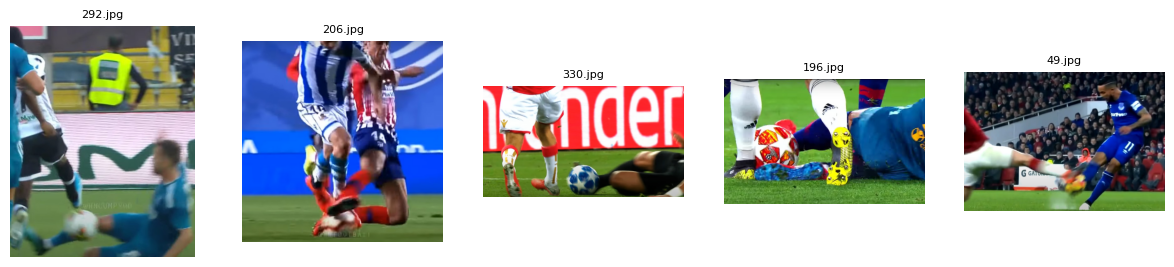

Sampling from var600/VAR
Class: Clean_Tackles


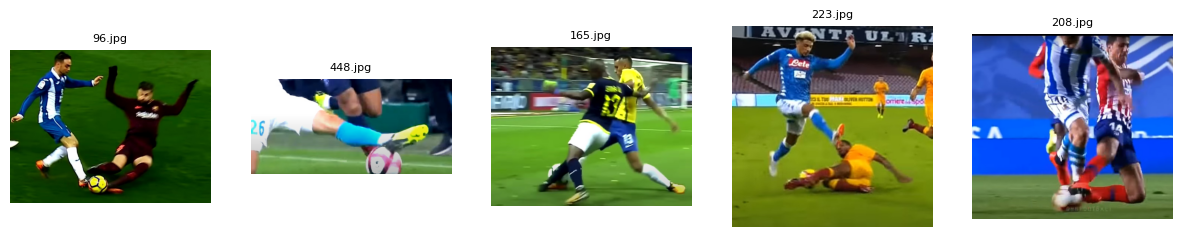

Sampling from var_200/VAR
Class: Clean_Tackles


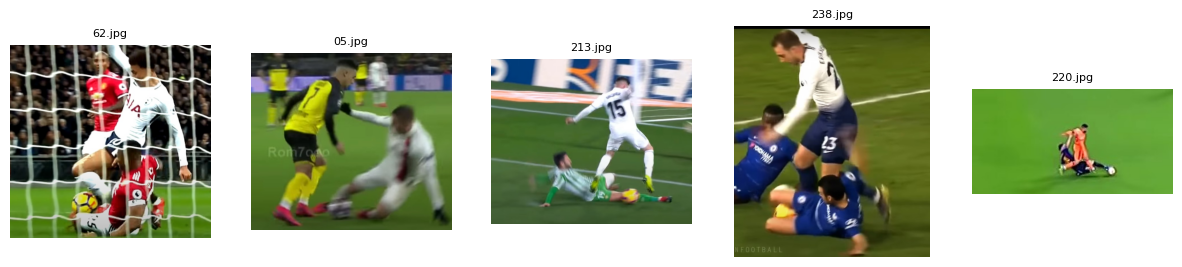

Sampling from var500/VAR
Class: Clean_Tackles


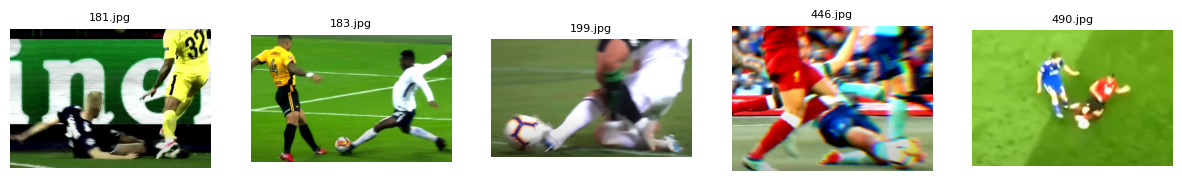

In [6]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random
import os

# Base folder where var_200, var400, var500, var600 live
base = os.path.join(kaggle_dataset_drive_path)
# Find all directories that start with "var"
var_dirs = [d for d in os.listdir(base) if d.startswith("var")]
# Build full paths to each "VAR" folder
data_paths = [os.path.join(base, var_d, "VAR") for var_d in var_dirs]
categories = ["Fouls", "Clean_Tackles"]

# Plot 5 random images from each category
for data_path in data_paths:
    print(f"Sampling from {os.path.basename(os.path.dirname(data_path))}/VAR")
    for category in ["Fouls", "Clean_Tackles"]:
        folder = os.path.join(data_path, category)
        images = os.listdir(folder)
        samples = random.sample(images, min(5, len(images)))

    print(f"Class: {category}")
    plt.figure(figsize=(15, 3))
    for i, img_file in enumerate(samples):
        img = mpimg.imread(os.path.join(folder, img_file))
        plt.subplot(1, 5, i + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(img_file, fontsize=8)
    plt.show()


## Checking Image Shapes and Sizes

In [7]:
from PIL import Image
import numpy as np

image_shapes = [] # Store the dimensions (width, height) of all images

# Loop through each class category
for data_path in data_paths:
    for category in categories:
        folder = os.path.join(data_path, category)
        for img_name in os.listdir(folder):
            img_path = os.path.join(folder, img_name)
            try:
                with Image.open(img_path) as img:
                    image_shapes.append(img.size)
            except:
                print(f"Corrupt image: {img_path}")

# Display unique image sizes
unique_shapes = set(image_shapes)
print(f"Number of unique image dimensions: {len(unique_shapes)}")
print("Sample dimensions:", list(unique_shapes)[:5])


Number of unique image dimensions: 1158
Sample dimensions: [(1436, 785), (611, 522), (787, 766), (1050, 740), (762, 691)]


## Class Distribution Check (Image Count)

In [8]:
from collections import Counter

image_counts = Counter()

for data_path in data_paths:
    for category in categories:
        folder = os.path.join(data_path, category)
        image_counts[category] += len(os.listdir(folder))

print("Total images per class across all VAR sets:")
for cat, cnt in image_counts.items():
    print(f"{cat}: {cnt} images")


Total images per class across all VAR sets:
Fouls: 1642 images
Clean_Tackles: 1738 images


## Visualize Class Distribution

<ipython-input-9-a5e1132348a8>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='class', y='count', data=df_counts, palette="Set2")


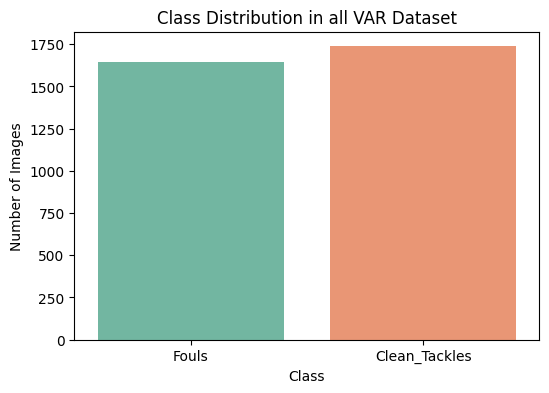

In [9]:
import seaborn as sns
import pandas as pd

# Convert to DataFrame for easier plotting
df_counts = pd.DataFrame.from_dict(image_counts, orient='index', columns=['count']).reset_index()
df_counts.columns = ['class', 'count']

# Plot
plt.figure(figsize=(6, 4))
sns.barplot(x='class', y='count', data=df_counts, palette="Set2")
plt.title("Class Distribution in all VAR Dataset")
plt.ylabel("Number of Images")
plt.xlabel("Class")
plt.show()


# 3. Pre-processing

In this step, we prepare the images before feeding them into the model. Preprocessing ensures uniformity in input shape and pixel values, and helps improve generalization through data augmentation.

## Resizing

We resize all images to `224x224`, a standard input size for CNN architectures.

In [10]:
from torchvision import transforms

# Resize image to 224x224 and convert to a PyTorch tensor
resize_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

## Normalization

We normalize the pixel values to the range `[-1, 1]` using a mean and standard deviation of `[0.5, 0.5, 0.5]` per RGB channel. This centers the data and speeds up training convergence.

In [11]:
# Normalizing image tensors to [-1, 1] range
# Using mean = [0.5, 0.5, 0.5] and std = [0.5, 0.5, 0.5] for RGB channels
normalize_transform = transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])

## Data augmentation

To reduce overfitting, we apply random transformations like:
* Horizontal flipping
* Rotation up to ±15°
* Brightness/contrast adjustments

In [12]:
# Apply random transformations
augmentation_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2)
])

In [13]:
# Final transform for training set (augmented + resized + normalized)
train_transform = transforms.Compose([
    resize_transform,
    augmentation_transform,
    normalize_transform
])

In [14]:
# Final transform for validation/test set (resize + normalize)
val_transform = transforms.Compose([
    resize_transform,
    normalize_transform
])

# 4. Data Splitting

Data Splitting involves dividing the dataset into distinct subsets for training, validation, and testing. The training set is used to train the model, the validation set helps tune hyperparameters, and the test set is used to evaluate the final model's performance.



The dataset is divided into three main subsets: `train`, `val`, and `test`, each containing two classes:

* `fallo/`: images depicting fouls
* `no_fallo/`: images depicting clean tackles (non-fouls)

```
/dataset/
├── train/
│   ├── fallo/
│   └── no_fallo/
├── val/
│   ├── fallo/
│   └── no_fallo/
├── test/
│   ├── fallo/
│   └── no_fallo/

```

In [15]:
import os

# Define base output path and class names
base_output = "dataset"
splits = ["train", "val", "test"]
labels = ["fallo", "no_fallo"]
# Define split ratios for train, validation, and test
split_ratio = [0.7, 0.15, 0.15]  # 70% train, 15% val, 15% test

# Create directories for each split and label
for split in splits:
    for label in labels:
        os.makedirs(os.path.join(base_output, split, label), exist_ok=True)

In [16]:
all_foul_images = []
all_clean_images = []

for data_path in data_paths:
    foul_dir = os.path.join(data_path, "Fouls")
    clean_dir = os.path.join(data_path, "Clean_Tackles")

    # Collect all image paths
    all_foul_images += [os.path.join(foul_dir, f) for f in os.listdir(foul_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    all_clean_images += [os.path.join(clean_dir, f) for f in os.listdir(clean_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

print(f"Lenght of foul images: {len(all_foul_images)}")
print(f"Lenght of clean tackles images: {len(all_foul_images)}")

Lenght of foul images: 1642
Lenght of clean tackles images: 1642


In [17]:
import shutil
import random

# Function to split and copy images
def split_and_copy(images, target_label):
    random.shuffle(images)  # Shuffle for randomness

    total = len(images)
    train_end = int(split_ratio[0] * total)
    val_end = train_end + int(split_ratio[1] * total)

    # Split images
    split_files = {
        "train": images[:train_end],
        "val": images[train_end:val_end],
        "test": images[val_end:]
    }

    # Copy images to respective folders
    for split in splits:
        for src_path in split_files[split]:
            dst_path = os.path.join(base_output, split, target_label, os.path.basename(src_path))
            shutil.copy(src_path, dst_path)

In [18]:
# Apply the splitting function to both classes
split_and_copy(all_foul_images, "fallo")
split_and_copy(all_clean_images, "no_fallo")

## Class Distribution & Balance Check

This step ensures that both categories (`fallo` and `no_fallo`) are fairly represented in the dataset, reducing the risk of bias during training.

In [19]:
from pathlib import Path

# Print image counts for each split and class
print("Final distribution of images:")
for split in splits:
    for label in labels:
        folder = Path(base_output) / split / label
        count = len(list(folder.glob("*")))
        print(f"{folder}: {count} images")

Final distribution of images:
dataset/train/fallo: 547 images
dataset/train/no_fallo: 551 images
dataset/val/fallo: 203 images
dataset/val/no_fallo: 220 images
dataset/test/fallo: 204 images
dataset/test/no_fallo: 214 images


# 5. Dataset and Dataloader

This step defines the full data pipeline for training a PyTorch model using a custom dataset. It includes:

* A custom `Dataset` class to load and transform images.
* A helper function to read image paths and assign labels.
* `DataLoader` wrappers to manage batching and loading.

## Define the Custom Dataset Class

This class loads individual image files, applies preprocessing (resize, normalize, augment), and returns the image and its label.

In [20]:
from torch.utils.data import Dataset
from PIL import Image
import torch

# Custom Dataset class to load foul/no_foul images
class FoulDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        # Open image and convert to RGB
        image = Image.open(self.image_paths[idx]).convert("RGB")
        label = self.labels[idx]

        # Apply transforms (resize, normalize, augment, etc.)
        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label)

## Load Image Paths and Labels

This utility function reads image paths from a directory and assigns labels based on folder names.

In [21]:
import os

# Returns two lists: image paths and corresponding labels
def load_image_paths_and_labels(root_dir):
    image_paths = []
    labels = []

    for class_name in ["no_fallo", "fallo"]:
        class_dir = os.path.join(root_dir, class_name)
        label = 0 if class_name == "no_fallo" else 1

        for fname in os.listdir(class_dir):
            if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                image_paths.append(os.path.join(class_dir, fname))
                labels.append(label)

    return image_paths, labels

## Create Dataset and DataLoaders

This part loads image paths and wraps datasets with PyTorch DataLoader to enable mini-batching and shuffling.

In [22]:
from torch.utils.data import DataLoader

# Load image paths and labels for training and validation sets
train_paths, train_labels = load_image_paths_and_labels("/content/dataset/train")
val_paths, val_labels = load_image_paths_and_labels("/content/dataset/val")

In [23]:
# Create PyTorch datasets using the custom class and transforms
train_dataset = FoulDataset(train_paths, train_labels, transform=train_transform)
val_dataset = FoulDataset(val_paths, val_labels, transform=val_transform)

In [24]:
# Wrap datasets in DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)

## Test Dataset Class Functionality

Here we test the custom dataset with a sample image and display it using matplotlib.


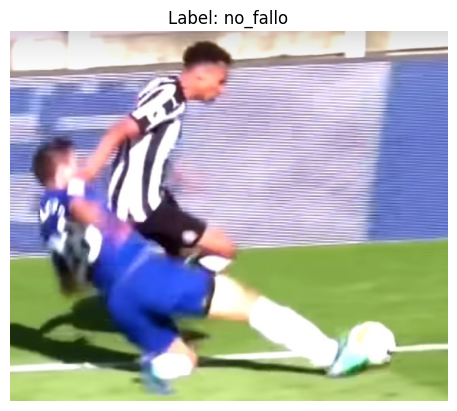

Total samples: 1098
Image type: <class 'PIL.Image.Image'>
Label type: <class 'torch.Tensor'>


In [25]:
import matplotlib.pyplot as plt

# Load dataset (no transforms for now)
train_dir = "/content/dataset/train"
image_paths, labels = load_image_paths_and_labels(train_dir)
dataset = FoulDataset(image_paths, labels)

# Pick one sample from the dataset
img, label = dataset[0]

# Display the image and its label
plt.imshow(img)
plt.title(f"Label: {'fallo' if label == 1 else 'no_fallo'}")
plt.axis("off")
plt.show()

# Print dataset stats
print(f"Total samples: {len(dataset)}")
print(f"Image type: {type(img)}")
print(f"Label type: {type(label)}")

## Test DataLoader

This test verifies that the `DataLoader` batches and resizes images correctly, and visualizes a batch.


In [26]:
# Load a batch from train_loader
images, labels = next(iter(train_loader))

# Check the shape of the batch
print(f"Batch size: {images.shape}")  # Expected: [32, 3, 224, 224]
print(f"Labels: {labels}")

Batch size: torch.Size([32, 3, 224, 224])
Labels: tensor([0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0,
        1, 0, 0, 0, 1, 0, 1, 0])


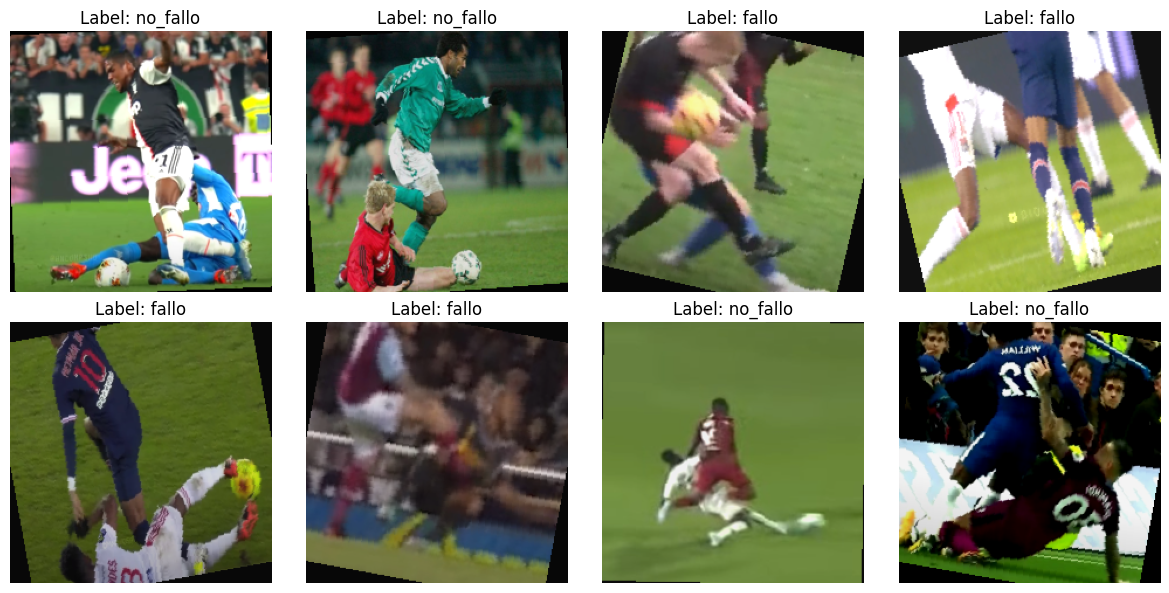

In [27]:
import numpy as np

# Visualize the first 8 images of the batch
plt.figure(figsize=(12, 6))
for i in range(8):
    img = images[i].permute(1, 2, 0).numpy()  # Convert from (C, H, W) to (H, W, C)
    img = (img * 0.5) + 0.5  # De-normalize
    img = np.clip(img, 0, 1)

    plt.subplot(2, 4, i + 1)
    plt.imshow(img)
    plt.title(f"Label: {'fallo' if labels[i] == 1 else 'no_fallo'}")
    plt.axis('off')

plt.tight_layout()
plt.show()

# 6. Model Construction

Model construction is the process of designing the neural network that will be trained to classify fouls. It involves stacking convolutional layers, applying activation functions, using pooling to downsample, and finishing with a classifier head to output predictions.

## Define the CNN Model Class

This block defines a custom convolutional neural network named `FoulClassifierCNN`.

In [28]:
import torch.nn as nn

# Custom CNN model for binary classification (foul vs no_foul)
class FoulClassifierCNN(torch.nn.Module):
    def __init__(self, num_classes=2):
        super(FoulClassifierCNN, self).__init__()

        self.features = nn.Sequential(
            # Block 1: Conv + BatchNorm + ReLU + MaxPool (input -> 112x112)
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),

            # Block 2: (112 -> 56)
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),

            # Block 3: (56 -> 28)
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),

            # Block 4: Adaptive average pooling to compress to 1x1
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)) # Output: [B, 256, 1, 1]
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),                  # Shape: [B, 256]
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)   # Final output: [B, 2]
        )

    def forward(self, x):
        x = self.features(x)    # Pass through conv layers
        x = self.classifier(x)  # Classify based on features
        return x


# 7. Model Training

This step covers the full training pipeline in PyTorch: from defining the optimizer and loss function, to implementing early stopping and logging metrics in TensorBoard.

## Setup and Initialization

We import all necessary libraries for training, optimization, logging, and scheduling. And define the model, loss function, optimizer, learning rate scheduler, early stopping configuration, and TensorBoard writer.

In [ ]:
import torch
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR, CosineAnnealingLR
import time
from torch.utils.tensorboard import SummaryWriter

# Instantiate model
model = FoulClassifierCNN()

# Loss function: Cross-entropy for classification
criterion = torch.nn.CrossEntropyLoss()

# Optimizer: Adam with low learning rate
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Learning rate scheduler: Cosine Annealing (can also try StepLR)
scheduler = CosineAnnealingLR(optimizer, T_max=10)

# Early stopping setup
early_stopping_patience = 10
best_val_loss = float('inf')
epochs_without_improvement = 0

# TensorBoard logger
writer = SummaryWriter()

## Training Loop Function

Encapsulates the training logic per epoch. Tracks metrics, updates weights, logs to TensorBoard, and handles early stopping and checkpoint saving.

In [ ]:
def train_model(train_loader, val_loader, num_epochs=20):
    global best_val_loss, epochs_without_improvement

    for epoch in range(num_epochs):
        model.train()  # Training mode
        running_loss = 0.0
        correct_predictions = 0
        total_predictions = 0

        # --- Training loop over batches ---
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total_predictions += labels.size(0)
            correct_predictions += (predicted == labels).sum().item()

        scheduler.step()

        # Logging training stats to TensorBoard
        writer.add_scalar('Training Loss', running_loss / len(train_loader), epoch)
        writer.add_scalar('Training Accuracy', correct_predictions / total_predictions, epoch)

        # --- Run validation ---
        val_loss, val_accuracy = validate_model(val_loader)
        writer.add_scalar('Validation Loss', val_loss, epoch)
        writer.add_scalar('Validation Accuracy', val_accuracy, epoch)

        # --- Print epoch summary ---
        print(f"Epoch [{epoch+1}/{num_epochs}]")
        print(f"Training Loss: {running_loss / len(train_loader):.4f}, Accuracy: {correct_predictions / total_predictions:.4f}")
        print(f"Validation Loss: {val_loss:.4f}, Accuracy: {val_accuracy:.4f}")

        # --- Early stopping logic ---
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_without_improvement = 0
            torch.save(model.state_dict(), "best_model.pth")  # Save model if it's the best so far


        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= early_stopping_patience:
            print("Early stopping triggered!")
            break

## Validation Function

Used to evaluate the model after each epoch without affecting gradients.

In [ ]:
def validate_model(val_loader):
    model.eval()  # Evaluation mode
    running_val_loss = 0.0
    correct_predictions = 0
    total_predictions = 0

    with torch.no_grad():  # No gradient computation needed
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total_predictions += labels.size(0)
            correct_predictions += (predicted == labels).sum().item()

    val_loss = running_val_loss / len(val_loader)
    val_accuracy = correct_predictions / total_predictions

    return val_loss, val_accuracy

## Launch the Training Process

Move the model to the appropriate device (GPU if available) and start training.

In [ ]:
# Set device (GPU if available, otherwise CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

# Start training
train_model(train_loader, val_loader, num_epochs=10)

Epoch [1/10]
Training Loss: 0.6687, Accuracy: 0.5918
Validation Loss: 0.6475, Accuracy: 0.6332
Epoch [2/10]
Training Loss: 0.6343, Accuracy: 0.6377
Validation Loss: 0.5981, Accuracy: 0.6694
Epoch [3/10]
Training Loss: 0.6322, Accuracy: 0.6169
Validation Loss: 0.6202, Accuracy: 0.6530
Epoch [4/10]
Training Loss: 0.6298, Accuracy: 0.6227
Validation Loss: 0.5785, Accuracy: 0.6939
Epoch [5/10]
Training Loss: 0.6161, Accuracy: 0.6444
Validation Loss: 0.5811, Accuracy: 0.6811
Epoch [6/10]
Training Loss: 0.6085, Accuracy: 0.6503
Validation Loss: 0.5757, Accuracy: 0.6881
Epoch [7/10]
Training Loss: 0.6203, Accuracy: 0.6469
Validation Loss: 0.5691, Accuracy: 0.6916
Epoch [8/10]
Training Loss: 0.6135, Accuracy: 0.6486
Validation Loss: 0.5670, Accuracy: 0.7044
Epoch [9/10]
Training Loss: 0.6024, Accuracy: 0.6678
Validation Loss: 0.5613, Accuracy: 0.6974
Epoch [10/10]
Training Loss: 0.6055, Accuracy: 0.6586
Validation Loss: 0.5624, Accuracy: 0.7068


# 8. Hyperparameter Tuning

Hyperparameter tuning is the process of finding the best combination of training configurations to maximize model performance. It typically involves:
* Learning rate (lr)
* Batch size
* Optimizer type (Adam, SGD, etc.)
* Number of filters in each convolutional block
* Dropout rate
* Scheduler type

## Finding the best combinations of parameters of the model

In [ ]:
!pip install optuna
import optuna
import torch
from torch.utils.data import DataLoader
import torch.nn as nn

# Hyperparameter tuning with Optuna

def objective(trial):
    # Suggest hyperparameters
    lr = trial.suggest_loguniform('lr', 1e-5, 1e-2)
    batch_size = trial.suggest_categorical('batch_size', [32, 64])
    dropout = trial.suggest_float('dropout', 0.2, 0.5)

    # Build model and apply dropout
    model = FoulClassifierCNN()
    model.classifier[3] = nn.Dropout(dropout)
    model.to(device)

    # Optimizer and scheduler
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

    # DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    # Train the model (with early stopping)
    train_model(train_loader, val_loader, num_epochs=10)

    # Evaluate on validation set
    val_loss, val_accuracy = validate_model(val_loader)

    return val_accuracy

# Create and run Optuna study automatically
print("Starting Optuna hyperparameter tuning...")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=2)

# Report best results
print('\nBest hyperparameters:', study.best_params)
print(f"Best validation accuracy: {study.best_value:.4f}\n")

# Rebuild and train final model with best params
best_params = study.best_params
best_config = (best_params['lr'], best_params['batch_size'], best_params['dropout'])
final_model = FoulClassifierCNN()
final_model.classifier[3] = nn.Dropout(best_params['dropout'])
final_model.to(device)

final_optimizer = torch.optim.Adam(final_model.parameters(), lr=best_params['lr'])
final_scheduler = torch.optim.lr_scheduler.StepLR(final_optimizer, step_size=5, gamma=0.5)

final_train_loader = DataLoader(train_dataset, batch_size=best_params['batch_size'], shuffle=True, num_workers=2, pin_memory=True)
final_val_loader = DataLoader(val_dataset, batch_size=best_params['batch_size'], shuffle=False, num_workers=2, pin_memory=True)

print("Retraining final model with best hyperparameters...")
train_model(final_train_loader, final_val_loader, num_epochs=10)

# Save final tuned model
torch.save(final_model.state_dict(), 'best_model_optuna.pth')
print('Saved final tuned model to best_model_optuna.pth')

[I 2025-05-29 14:51:00,408] A new study created in memory with name: no-name-35f8a5a9-7eb3-456a-8da6-e477fa542f92


Starting Optuna hyperparameter tuning...


<ipython-input-87-b5ff1536ac03>:11: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr = trial.suggest_loguniform('lr', 1e-5, 1e-2)


Epoch [1/10]
Training Loss: 0.5942, Accuracy: 0.6878
Validation Loss: 0.5639, Accuracy: 0.6974
Epoch [2/10]
Training Loss: 0.5913, Accuracy: 0.6778
Validation Loss: 0.5566, Accuracy: 0.7091
Epoch [3/10]
Training Loss: 0.5985, Accuracy: 0.6611
Validation Loss: 0.5579, Accuracy: 0.7138
Epoch [4/10]
Training Loss: 0.5839, Accuracy: 0.6903
Validation Loss: 0.5469, Accuracy: 0.7091
Epoch [5/10]
Training Loss: 0.5918, Accuracy: 0.6803
Validation Loss: 0.5517, Accuracy: 0.7196
Epoch [6/10]
Training Loss: 0.5902, Accuracy: 0.6745
Validation Loss: 0.5440, Accuracy: 0.7196
Epoch [7/10]
Training Loss: 0.5867, Accuracy: 0.6803
Validation Loss: 0.5403, Accuracy: 0.7418
Epoch [8/10]
Training Loss: 0.5908, Accuracy: 0.6828
Validation Loss: 0.5494, Accuracy: 0.7161
Epoch [9/10]
Training Loss: 0.5776, Accuracy: 0.6895
Validation Loss: 0.5347, Accuracy: 0.7418
Epoch [10/10]
Training Loss: 0.5714, Accuracy: 0.6970
Validation Loss: 0.5271, Accuracy: 0.7266


[I 2025-05-29 15:43:25,482] Trial 0 finished with value: 0.7266355140186916 and parameters: {'lr': 4.2993192146683364e-05, 'batch_size': 64, 'dropout': 0.4878499129728351}. Best is trial 0 with value: 0.7266355140186916.


Epoch [1/10]
Training Loss: 0.5743, Accuracy: 0.6970
Validation Loss: 0.5499, Accuracy: 0.7103
Epoch [2/10]
Training Loss: 0.5662, Accuracy: 0.6886
Validation Loss: 0.5424, Accuracy: 0.7231
Epoch [3/10]
Training Loss: 0.5796, Accuracy: 0.6853
Validation Loss: 0.5123, Accuracy: 0.7395
Epoch [4/10]
Training Loss: 0.5715, Accuracy: 0.6845
Validation Loss: 0.5209, Accuracy: 0.7395
Epoch [5/10]
Training Loss: 0.5618, Accuracy: 0.7112
Validation Loss: 0.5137, Accuracy: 0.7348
Epoch [6/10]
Training Loss: 0.5501, Accuracy: 0.7137
Validation Loss: 0.5085, Accuracy: 0.7523
Epoch [7/10]
Training Loss: 0.5496, Accuracy: 0.7053
Validation Loss: 0.5022, Accuracy: 0.7582
Epoch [8/10]
Training Loss: 0.5450, Accuracy: 0.7295
Validation Loss: 0.5032, Accuracy: 0.7593
Epoch [9/10]
Training Loss: 0.5555, Accuracy: 0.7229
Validation Loss: 0.5052, Accuracy: 0.7535
Epoch [10/10]
Training Loss: 0.5509, Accuracy: 0.7154
Validation Loss: 0.5027, Accuracy: 0.7523


[I 2025-05-29 16:33:29,556] Trial 1 finished with value: 0.7523364485981309 and parameters: {'lr': 2.2715690446456368e-05, 'batch_size': 32, 'dropout': 0.28679533739874485}. Best is trial 1 with value: 0.7523364485981309.



Best hyperparameters: {'lr': 2.2715690446456368e-05, 'batch_size': 32, 'dropout': 0.28679533739874485}
Best validation accuracy: 0.7523

Retraining final model with best hyperparameters...
Epoch [1/10]
Training Loss: 0.5360, Accuracy: 0.7220
Validation Loss: 0.5029, Accuracy: 0.7477
Epoch [2/10]
Training Loss: 0.5686, Accuracy: 0.6912
Validation Loss: 0.5126, Accuracy: 0.7290
Epoch [3/10]
Training Loss: 0.5548, Accuracy: 0.7028
Validation Loss: 0.5038, Accuracy: 0.7442
Epoch [4/10]
Training Loss: 0.5533, Accuracy: 0.7104
Validation Loss: 0.5101, Accuracy: 0.7465
Epoch [5/10]
Training Loss: 0.5530, Accuracy: 0.6928
Validation Loss: 0.4982, Accuracy: 0.7313
Epoch [6/10]
Training Loss: 0.5453, Accuracy: 0.7187
Validation Loss: 0.4914, Accuracy: 0.7512
Epoch [7/10]
Training Loss: 0.5547, Accuracy: 0.7095
Validation Loss: 0.4961, Accuracy: 0.7430
Epoch [8/10]
Training Loss: 0.5557, Accuracy: 0.7179
Validation Loss: 0.4770, Accuracy: 0.7722
Epoch [9/10]
Training Loss: 0.5362, Accuracy: 0.72

## Final Training on Train + Val

In [ ]:
from torch.utils.data import ConcatDataset, DataLoader

# Merge train and val sets
combined_dataset = ConcatDataset([train_dataset, val_dataset])
final_loader = DataLoader(combined_dataset, batch_size=best_config[1], shuffle=True)

# Rebuild final model with best config
model = FoulClassifierCNN()
model.classifier[3] = nn.Dropout(best_config[2])
model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=best_config[0])
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

criterion = nn.CrossEntropyLoss()

print("Starting final training on full dataset...")

# Final training loop with logging
for epoch in range(10):
    model.train()
    running_loss = 0.0
    total_batches = 0

    for images, labels in final_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        total_batches += 1

    scheduler.step()
    avg_loss = running_loss / total_batches
    print(f"Epoch [{epoch+1}/10] - Average Loss: {avg_loss:.4f}")

print("Final training completed.")

# Save final model
torch.save(model.state_dict(), "final_model.pth")
print("Final model saved to final_model.pth")

Starting final training on full dataset...
Epoch [1/10] - Average Loss: 0.6761
Epoch [2/10] - Average Loss: 0.6435
Epoch [3/10] - Average Loss: 0.6268
Epoch [4/10] - Average Loss: 0.6184
Epoch [5/10] - Average Loss: 0.6039
Epoch [6/10] - Average Loss: 0.5944
Epoch [7/10] - Average Loss: 0.5884
Epoch [8/10] - Average Loss: 0.5923
Epoch [9/10] - Average Loss: 0.5899
Epoch [10/10] - Average Loss: 0.5825
Final training completed.
Final model saved to final_model.pth


## Saving the trained model on google drive
It saves the model in the google drive after that the training is done



In [ ]:
import shutil

# Path to the locally saved model (after training)
local_model_path = "final_model.pth"

# Destination path on Google Drive (adjust if you want a different folder)
drive_model_path = "/content/drive/MyDrive/Football_Fouls_Project/final_model.pth"

# Copy the model file from local storage to Google Drive
shutil.copy(local_model_path, drive_model_path)

print(f"Model copied to Drive at: {drive_model_path}")


Model copied to Drive at: /content/drive/MyDrive/Football_Fouls_Project/final_model.pth


# 9. Model Evaluation

This phase evaluates how well the trained CNN generalizes on unseen test data, using standard metrics and visualizations like the confusion matrix.


## Load Test Dataset

We prepare the test dataset with the same transformations used in validation, and load it with a DataLoader.

In [29]:
test_paths, test_labels = load_image_paths_and_labels("/content/dataset/test")
test_dataset = FoulDataset(test_paths, test_labels, transform=val_transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

## Load Best Trained Model

We reload the best model saved during training, move it to the appropriate device, and set it to evaluation mode.

Load the trained model weights either from Google Drive or from the local path.

This helps switch between environments (e.g., Colab with Drive vs. local development)

In [30]:
import torch
import os

# We can choose from where load the model: True = Google Drive, False = local on coLab
load_from_drive = True

# Path of the models
local_model_path = "final_model.pth"
drive_model_path = "/content/drive/MyDrive/Football_Fouls_Project/final_model.pth"

# Select the  device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Initialize the model
model = FoulClassifierCNN()

# uploading the model based on the choice
model_path = drive_model_path if load_from_drive else local_model_path

if os.path.exists(model_path):
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    model.eval()
    print(f"Model uploaded from: {'Google Drive' if load_from_drive else 'local'}")
else:
    print(f"File not found in  {model_path}")

Model uploaded from: Google Drive


## Evaluate Model Performace on Test Set

Loop through the test set and collect model predictions and true labels. This is used to evaluate the final performance of the trained model on unseen data.

In [31]:
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

## Compute Evaluation Metrics

We compute accuracy, precision, recall, F1-score, and show a detailed breakdown using `classification_report`.

In [32]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

accuracy = accuracy_score(all_labels, all_preds)
conf_matrix = confusion_matrix(all_labels, all_preds)
report = classification_report(all_labels, all_preds, target_names=["no_fallo", "fallo"])

print(f"Test Accuracy: {accuracy:.4f}")
print("\nClassification Report:\n", report)

Test Accuracy: 0.7512

Classification Report:
               precision    recall  f1-score   support

    no_fallo       0.79      0.70      0.74       214
       fallo       0.72      0.80      0.76       204

    accuracy                           0.75       418
   macro avg       0.75      0.75      0.75       418
weighted avg       0.76      0.75      0.75       418



## Confusion Matrix Visualization

Use seaborn to show a heatmap of the confusion matrix. This helps visually assess the model's mistakes.

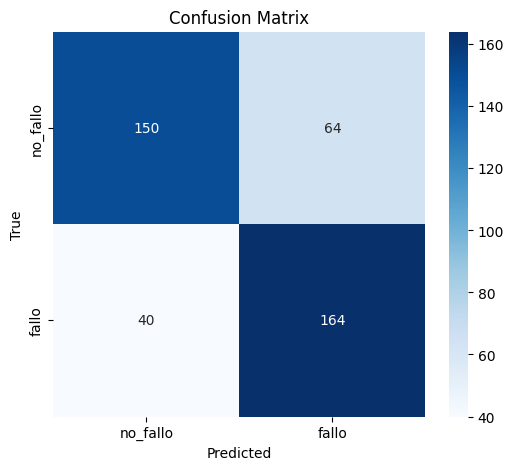

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=["no_fallo", "fallo"],
            yticklabels=["no_fallo", "fallo"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

In [34]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve

# Otteniamo le probabilità per la classe "fallo" (indice 1)
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        all_probs.extend(probs[:, 1].cpu().numpy())  # Probabilità classe "fallo"


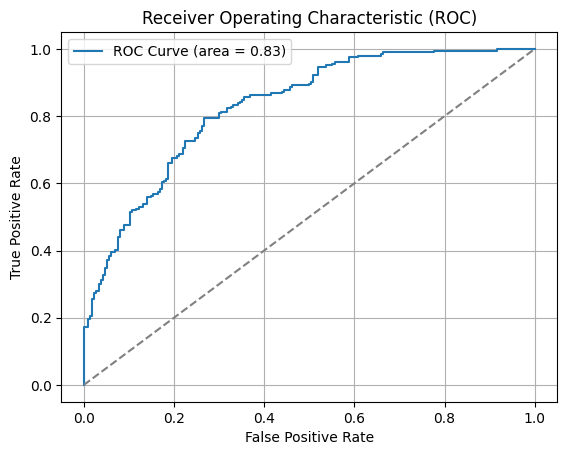

In [35]:
fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"ROC Curve (area = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC)")
plt.legend()
plt.grid()
plt.show()


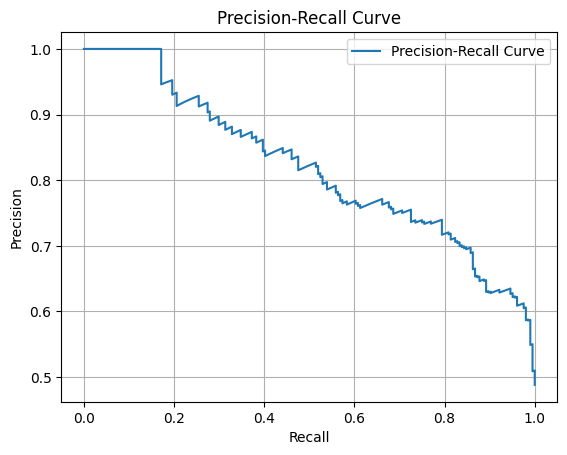

In [37]:
precision, recall, _ = precision_recall_curve(all_labels, all_probs)

plt.figure()
plt.plot(recall, precision, label="Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid()
plt.legend()
plt.show()


<ipython-input-36-952a8a9d2d5d>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metrics, y=values, palette="Set2")


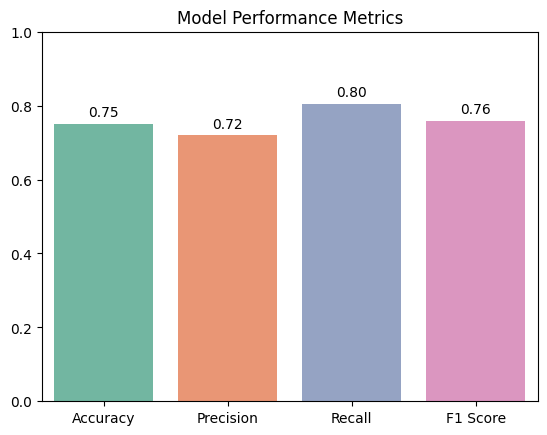

In [36]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision_val = precision_score(all_labels, all_preds)
recall_val = recall_score(all_labels, all_preds)
f1_val = f1_score(all_labels, all_preds)

plt.figure()
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]
values = [accuracy, precision_val, recall_val, f1_val]
sns.barplot(x=metrics, y=values, palette="Set2")
plt.ylim(0, 1)
plt.title("Model Performance Metrics")
for i, v in enumerate(values):
    plt.text(i, v + 0.02, f"{v:.2f}", ha="center")
plt.show()
